# Phase 2: Data Exploration

| | |
|---|---|
| **Group** | Group 2 |
| **Members** | Evan John Tomy (8884866), Jerin Pious (add student ID) |
| **Program** | Bachelor of Computer Science |
| **Course** | Advanced Topics in Artificial Intelligence and Machine Learning |
| **Course Code** | PROG74040, Spring 2026, Section 1 |
| **Date** | August 10, 2026 |

---

**Notebook 1 of 5** reads the raw Kaggle files only; nothing is saved here. Its findings directly shape every cleaning and modelling decision made in the notebooks that follow.

## Purpose
Before writing a single line of preprocessing or modelling code, this notebook verifies what the Jigsaw Toxic Comment dataset actually contains, its size, class balance, data-quality issues, and real comment text, against the claims made in the Phase 1 proposal. Every number here is computed over the **full** dataset, not a sample.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv/train.csv")
test = pd.read_csv("test.csv/test.csv")
test_labels = pd.read_csv("test_labels.csv/test_labels.csv")

LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print("train:", train.shape)
print("test:", test.shape)
print("test_labels:", test_labels.shape)
train.head()

train: (159571, 8)
test: (153164, 2)
test_labels: (153164, 7)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [2]:
print("Missing comment_text (train):", train["comment_text"].isna().sum())
print("Missing comment_text (test):", test["comment_text"].isna().sum())
print("Duplicate comment_text rows (train):", train["comment_text"].duplicated().sum())

Missing comment_text (train): 0
Missing comment_text (test): 0
Duplicate comment_text rows (train): 0


**What this confirms**: the dataset matches the Phase 1 proposal's description exactly, with 159,571 training comments and 153,164 test comments and the expected `id` / `comment_text` / six binary label columns. Zero missing text and zero duplicate comments in `train.csv` means there's no need for a null-handling or deduplication step later; the dataset is clean at this level from the start.

               count  pct_of_train
toxic          15294          9.58
obscene         8449          5.29
insult          7877          4.94
severe_toxic    1595          1.00
identity_hate   1405          0.88
threat           478          0.30

Non-toxic: 143346 (89.8%)
Multi-label (2+ categories): 9865 (6.2%)


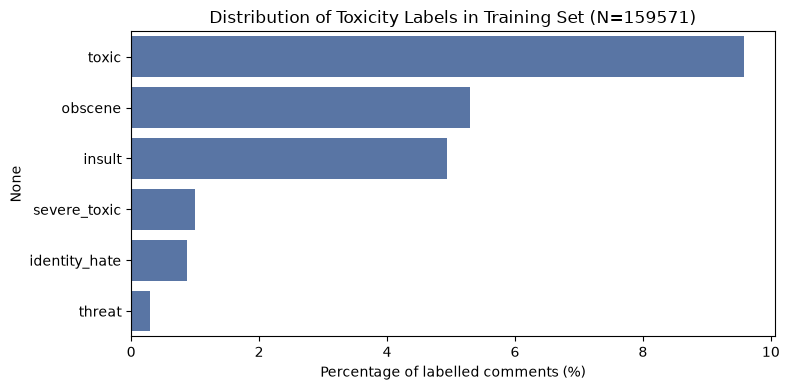

In [3]:
label_counts = train[LABEL_COLS].sum().sort_values(ascending=False)
label_pct = (label_counts / len(train) * 100).round(2)
dist = pd.DataFrame({"count": label_counts, "pct_of_train": label_pct})
print(dist)

non_toxic = (train[LABEL_COLS].sum(axis=1) == 0).sum()
multi_label = (train[LABEL_COLS].sum(axis=1) > 1).sum()
print(f"\nNon-toxic: {non_toxic} ({non_toxic/len(train)*100:.1f}%)")
print(f"Multi-label (2+ categories): {multi_label} ({multi_label/len(train)*100:.1f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=label_pct.values, y=label_pct.index, orient="h", color="#4C72B0")
plt.xlabel("Percentage of labelled comments (%)")
plt.title(f"Distribution of Toxicity Labels in Training Set (N={len(train)})")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()

**The core imbalance, in numbers**: 89.8% of comments are non-toxic; the six categories don't split the remaining 10.2% evenly. `toxic` alone covers 9.58%, but `threat` (0.30%) and `identity_hate` (0.88%) are genuinely rare, under 1 in 100 comments. This is the single biggest challenge for this project: a model that just predicts "not toxic" for everything would already be ~90% "accurate" while being completely useless. Every imbalance-handling decision from Notebook 2 onward (class weights, stratified splits, the augmentation experiment) exists because of this chart.

In [4]:
unscored = (test_labels[LABEL_COLS] == -1).all(axis=1)
print(f"Unscored rows (-1 placeholder): {unscored.sum()} of {len(test_labels)}")
print(f"Usable labeled test rows: {(~unscored).sum()}")

Unscored rows (-1 placeholder): 89186 of 153164
Usable labeled test rows: 63978


**Why this matters for the whole project**: 89,186 of the 153,164 test rows (58%) are `-1` placeholders, Kaggle's way of marking rows that were never scored publicly. Only the remaining 63,978 rows have real labels. This isn't just trivia. Notebook 5's entire methodology depends on it: those 63,978 usable rows become the *only* genuinely held-out test set in this project, never touched by training, validation, or threshold tuning for any model.

count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: word_count, dtype: float64


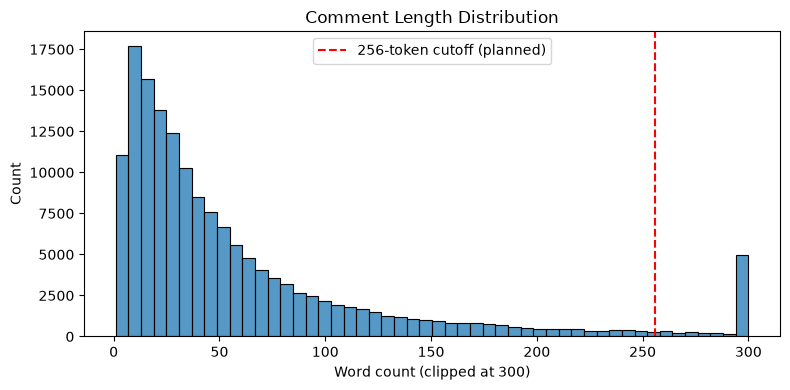

In [5]:
train["word_count"] = train["comment_text"].str.split().str.len()
print(train["word_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train["word_count"].clip(upper=300), bins=50)
plt.axvline(256, color="red", linestyle="--", label="256-token cutoff (planned)")
plt.xlabel("Word count (clipped at 300)")
plt.legend()
plt.title("Comment Length Distribution")
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150)
plt.show()

**Word-count shape**: median comment length is 36 words, but the distribution has a long tail: some comments run past 1,400 words. Most of the mass sits well under 256 words, which is the first signal (refined precisely with the actual tokenizer in Notebook 2) that a 256-token cutoff is a reasonable balance between coverage and compute cost, rather than an arbitrary round number.

## Content & Structure Deep-Dive

Full-dataset pattern scans (HTML tags, wiki markup, IP addresses, non-ASCII text) plus actual sampled comment text per label, so the dataset's real content, not just its aggregate statistics, has been directly reviewed.

In [6]:
pd.set_option("display.max_colwidth", 120)

def content_signals(series):
    html = series.str.contains(r"<[^>]+>", regex=True, na=False)
    wiki_markup = series.str.contains(r"(==.+==|\[\[.+\]\]|\{\{.+\}\})", regex=True, na=False)
    ip_address = series.str.contains(r"\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b", regex=True, na=False)
    non_ascii_ratio = series.apply(lambda t: sum(1 for c in t if ord(c) > 127) / max(len(t), 1))
    all_caps = series.str.isupper()
    return pd.DataFrame({
        "html_tags": html, "wiki_markup": wiki_markup,
        "ip_address": ip_address, "non_ascii_ratio": non_ascii_ratio, "all_caps": all_caps,
    })

train_signals = content_signals(train["comment_text"])
print("=== train.csv content signals (full dataset, N=159,571) ===")
print("Rows with HTML tags:      ", train_signals["html_tags"].sum(), f"({train_signals['html_tags'].mean()*100:.2f}%)")
print("Rows with wiki markup:    ", train_signals["wiki_markup"].sum(), f"({train_signals['wiki_markup'].mean()*100:.2f}%)")
print("Rows with IP addresses:   ", train_signals["ip_address"].sum(), f"({train_signals['ip_address'].mean()*100:.2f}%)")
print("Rows >20% non-ASCII chars:", (train_signals["non_ascii_ratio"] > 0.2).sum())
print("Fully upper-case rows:    ", train_signals["all_caps"].sum())

print("\n=== Sample comments by label (train.csv) ===")
for label in LABEL_COLS:
    print(f"\n--- {label} ---")
    for text in train[train[label] == 1]["comment_text"].sample(3, random_state=42):
        print(" -", text.replace("\n", " ")[:180])

print("\n--- clean (all labels 0) ---")
for text in train[train[LABEL_COLS].sum(axis=1) == 0]["comment_text"].sample(3, random_state=42):
    print(" -", text.replace("\n", " ")[:180])

C:\Users\evanj\AppData\Local\Temp\ipykernel_36972\87427400.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  wiki_markup = series.str.contains(r"(==.+==|\[\[.+\]\]|\{\{.+\}\})", regex=True, na=False)


=== train.csv content signals (full dataset, N=159,571) ===
Rows with HTML tags:       84 (0.05%)
Rows with wiki markup:     3018 (1.89%)
Rows with IP addresses:    9816 (6.15%)
Rows >20% non-ASCII chars: 35
Fully upper-case rows:     1702

=== Sample comments by label (train.csv) ===

--- toxic ---
 - Hi!   I wanna rape you!
 - Terrorize  I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threat
 - Being blocked  So that's your idea of mediation, is it? R Lopez can run amok through Wikipedia with his lying crap, and I get blocked for stating my intention of stopping him unles

--- severe_toxic ---
 - "   WHAT  IN THE FUCK ARE YOU REFERRING TOO   I HAVE NO IDEA WHAT THE PISS YOU'RE REFERRING TOO, OR WHY YOU BOTHERED TO WRITE ME.  LISTEN I'VE ADDED PLENTY TO THESE PAGE INCLUDING 
 - takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  tak

**What the content scan and sample review found**: HTML is rare (0.05%), but wiki markup and IP addresses are common enough to matter (1.89% and 6.15% of rows), and both get addressed in Notebook 2's cleaning step. The sampled comments confirm the labels behave sensibly: `threat` examples are literal statements of intent to find and harm someone; `identity_hate` examples target ethnic and religious groups specifically; `toxic` alone catches broader hostility without a specific target. One clean-sample comment contained a `�` replacement character, direct evidence of an encoding artifact already present in the raw data, confirming the Unicode-normalization step in Notebook 2 is addressing a real, observed problem, not a theoretical one.

In [7]:
print("=== test.csv content signals (full dataset, N=153,164) ===")
test_signals = content_signals(test["comment_text"])
print("Rows with HTML tags:      ", test_signals["html_tags"].sum(), f"({test_signals['html_tags'].mean()*100:.2f}%)")
print("Rows with wiki markup:    ", test_signals["wiki_markup"].sum(), f"({test_signals['wiki_markup'].mean()*100:.2f}%)")
print("Rows with IP addresses:   ", test_signals["ip_address"].sum(), f"({test_signals['ip_address'].mean()*100:.2f}%)")

print("\n=== Sample rows (test.csv) ===")
for text in test["comment_text"].sample(5, random_state=42):
    print(" -", text.replace("\n", " ")[:180])

print("\n=== Label distribution among USABLE test_labels rows only (excludes -1 placeholders) ===")
usable = test_labels[~unscored]
usable_counts = usable[LABEL_COLS].sum().sort_values(ascending=False)
usable_pct = (usable_counts / len(usable) * 100).round(2)
print(pd.DataFrame({"count": usable_counts, "pct_of_usable_test": usable_pct}))

=== test.csv content signals (full dataset, N=153,164) ===


C:\Users\evanj\AppData\Local\Temp\ipykernel_36972\87427400.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  wiki_markup = series.str.contains(r"(==.+==|\[\[.+\]\]|\{\{.+\}\})", regex=True, na=False)


Rows with HTML tags:       71 (0.05%)
Rows with wiki markup:     45638 (29.80%)
Rows with IP addresses:    746 (0.49%)

=== Sample rows (test.csv) ===
 - == Sky city ==    Hello,    I noticed that you were involved in WikiProject Skyscrapers, and I thought you could help me. I am trying to take Skycity to DYK, considering what an in
 - "    ""Specifically, Allied forces suffered approximately 14.2 million deaths, and Axis forces suffered approximately 6.8 million deaths, Germany specifically had 5 million. The So
 - "   You know what, I think you're just insecure and went on the attack because I was ""winning"" the issue at hand over on the CfD you've come here from; I think you've picked a sp
 - "    == LOL ==    LOLLOLOLOLOOLOLLOLOLOLLOL       is that the only topic of this page? sonic, proxies and as martin fucking bazley would say ""Juveniles"" hahahahahah what a noob p
 - he is not a bad guy he is a sexy guy and his birthday is February 24, 1977 get strait bitches

=== Label distr

## Summary
The dataset matches its Phase 1 description, is clean at the row level (no missing/duplicate text), and has the expected ~90/10 imbalance with `threat` and `identity_hate` as the genuinely rare categories. Wiki markup and encoding artifacts are real, measurable issues that Notebook 2's cleaning step needs to handle, and does. The 63,978 usable rows in `test_labels.csv` are reserved as the project's only true held-out evaluation set, used exclusively in Notebook 5.